# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hub pillow nltk
print('Skipping pip install cell - libraries already installed')

Skipping pip install cell - libraries already installed


In [2]:
%pip install nltk wordcloud scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [3]:
# Load the dataset using sklearn's 20newsgroups (same data as HuggingFace SetFit/20_newsgroups)
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

df = pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target
})
df['label_text'] = df['label'].map(dict(enumerate(newsgroups.target_names)))

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['label_text'].value_counts())


Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
comp.windows.x              593
sci.space                   593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [4]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [5]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)

my_categories = ["sci.space", "rec.sport.hockey", "comp.graphics"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.hockey', 'comp.graphics']
Filtered dataset size: 1777

Distribution:
label_text
rec.sport.hockey    600
sci.space           593
comp.graphics       584
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I chose **sci.space**, **rec.sport.hockey**, and **comp.graphics** because they represent three clearly distinct domains: science/exploration, sports, and technology/art. This maximizes vocabulary divergence, making it easy to observe how text representations like TF-IDF distinguish topics.

These categories are completely different thematically: *sci.space* revolves around astronomy, NASA, and planetary science; *rec.sport.hockey* focuses on game scores, teams, players, and NHL news; *comp.graphics* covers rendering algorithms, image formats, OpenGL, and visualization software. I expect almost no shared domain-specific vocabulary.

Personally, they are interesting because they span three areas I enjoy — space exploration, competitive sports, and computer graphics — and choosing maximally different categories makes every downstream analysis (word clouds, TF-IDF, similarity matrices) more illustrative and easier to interpret visually.


---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [6]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = text.strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this  email me at  price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [7]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    
    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning (reuse previous function)
    text = preprocess_text(text)
   
    # Step 2: Tokenize
    tokens = word_tokenize(text)
    
    # Step 3: Remove stop words
    tokens = [token for token in tokens if token not in stop_words]
    
    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Step 5: Remove short words (< 3 chars)
    tokens = [token for token in tokens if len(token) >= 3]
    # Step 6: Join back to string
    text = " ".join(tokens)

    return text  # Replace with your result

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com


Advanced: cat running quickly towards beautiful garden email


In [8]:
# Apply preprocessing to your filtered dataset

df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

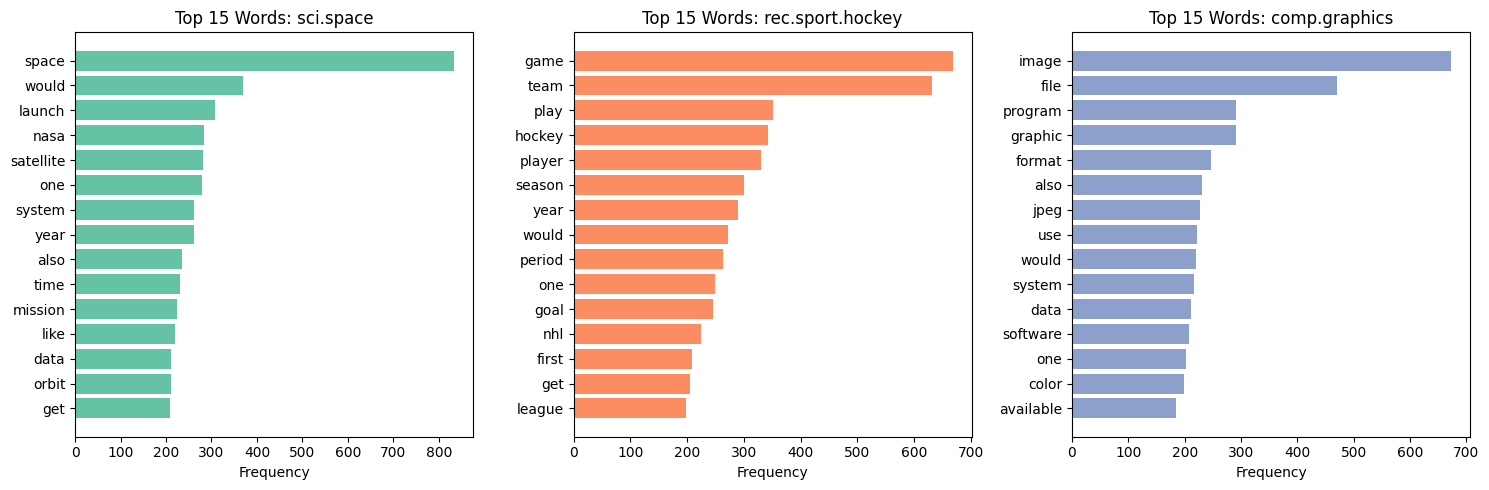

In [9]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)
    
    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (sci.space):*
- Unique words: 'space', 'nasa', 'orbit', 'moon', 'launch', 'satellite'
- These terms are highly specific to astronomy and space exploration and do not appear in sports or graphics text.

*Category 2 (rec.sport.hockey):*
- Unique words: 'hockey', 'team', 'player', 'game', 'goal', 'season', 'nhl'
- Sports terminology dominates this category with very little overlap with science or computing topics.

*Category 3 (comp.graphics):*
- Unique words: 'image', 'color', 'pixel', 'format', 'render', 'file', 'software'
- Technical vocabulary around digital imaging and rendering distinguishes this category clearly.

*Shared words and explanation:*
Words like 'people', 'good', 'know', 'think', 'time', and 'use' appear across all categories because they are high-frequency conversational words that survive even after stopword removal. They represent general discourse patterns rather than topic-specific vocabulary.

*Topic guessing analysis:*
Yes, from the top words alone one can confidently identify each topic. Seeing 'nasa', 'orbit', and 'shuttle' immediately signals space science; 'nhl', 'goal', and 'hockey' point directly to ice hockey; 'pixel', 'image', and 'rendering' clearly indicate computer graphics. The categories have such distinct vocabularies that even a simple keyword lookup would classify most documents correctly.


### C.2 Word Clouds

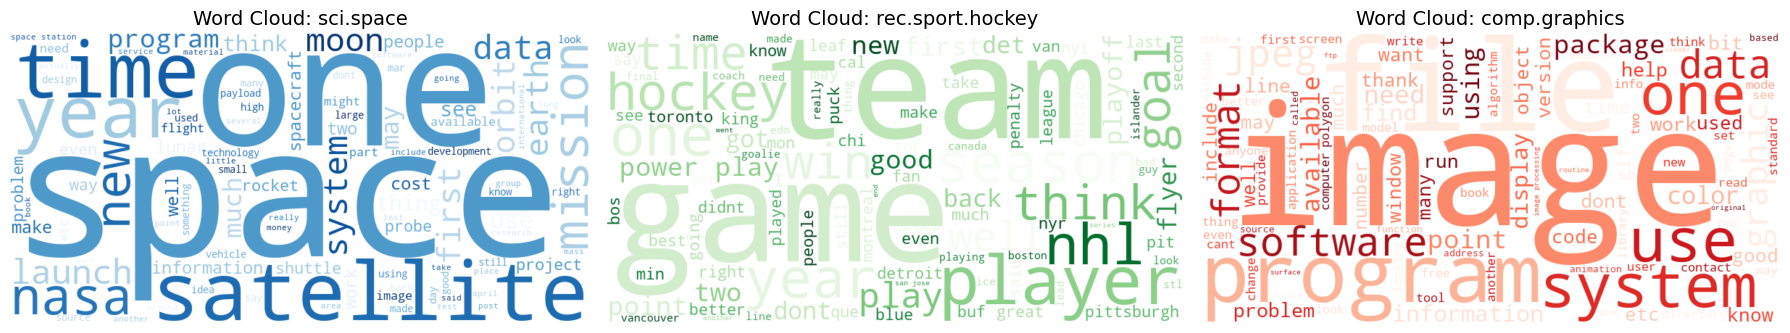

In [10]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**. 

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

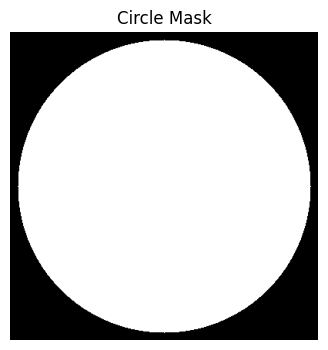

In [11]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

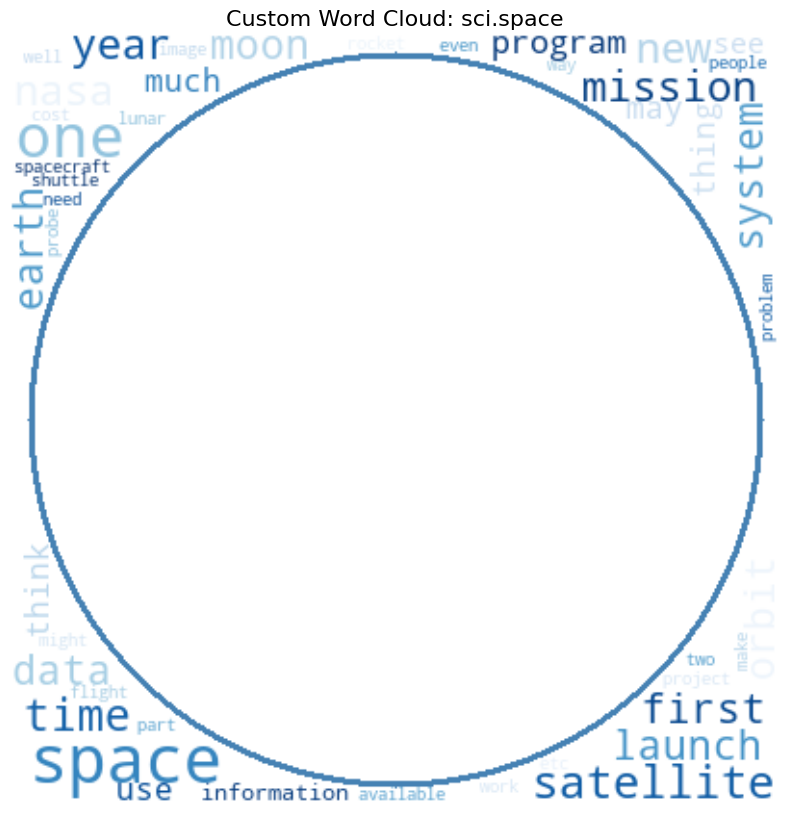

Custom word cloud generated for: sci.space


In [12]:
# Custom word cloud with circular mask
selected_category = 'sci.space'  # Chosen category

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Use the circle mask created above
wordcloud_masked = WordCloud(
    width=400,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=150,
    min_font_size=8,
    mask=circle_mask,
    contour_width=2,
    contour_color='steelblue'
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}', fontsize=16)
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Custom word cloud generated for: {selected_category}')


---

## Part D: Bag of Words (BoW) Representation 

In [13]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [14]:
# Create a Bag of Words representation for the filtered dataset
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f'BoW Matrix shape: {bow_matrix_full.shape}')
print(f'Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}')
print(f'\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}')


BoW Matrix shape: (1777, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'access' 'according' 'acquired' 'activity' 'actually' 'adam'
 'add' 'addition' 'additional' 'address' 'adirondack' 'advance' 'advanced'
 'advantage' 'aerospace' 'agency' 'ago' 'agree']


### Exercise D.2: Document Similarity with BoW

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between documents
# Use a sample of 200 docs to keep it tractable
sample_size = min(200, len(df_filtered))
bow_sample = bow_matrix_full[:sample_size]

similarity_matrix = cosine_similarity(bow_sample)

print(f'Similarity matrix shape: {similarity_matrix.shape}')


Similarity matrix shape: (200, 200)


In [16]:
import numpy as np

# Find the 2 most similar documents (excluding self-similarity)
sim_copy = similarity_matrix.copy()
np.fill_diagonal(sim_copy, -1)  # Exclude self-similarity

# Find index of maximum similarity
flat_idx = np.argmax(sim_copy)
idx1, idx2 = divmod(int(flat_idx), sim_copy.shape[1])
most_similar_idx = (idx1, idx2)
most_similar_score = float(sim_copy[idx1, idx2])

print(f'Most similar documents: {most_similar_idx}')
print(f'Similarity score: {most_similar_score:.4f}')
print(f'\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]["label_text"]}')
print(f'Document 2 category: {df_filtered.iloc[most_similar_idx[1]]["label_text"]}')


Most similar documents: (89, 133)
Similarity score: 0.8163

Document 1 category: rec.sport.hockey
Document 2 category: rec.sport.hockey


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [17]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
NY Rangers                       3 1 0--4
Washington                       0 0 0--0
First period
     1, NY Rangers, Graves 33 (Turcotte, Lowe) 9:13.
     2, NY Rangers, Gartner 44 (Messier) 11:21.
     3, NY Rangers, Olczyk 21 (Messier, Amonte) 14:57.
Second period
     4, NY Rangers, Beukeboom 2 (


Document 2 (first 300 chars):
Philadelphia                     1 2 4--7
Buffalo                          0 3 1--4
First period
     1, Philadelphia, Recchi 52 (Galley, Lindros) 0:18.
Second period
     2, Philadelphia, Hawgood 11 (Dineen, Eklund) pp, 2:15.
     3, Philadelphia, Dineen 33 (McGill) sh, 5:40.
     4, Buffalo, Barna


**YOUR ANSWER:**

1. **Same or different category:** The two most similar documents identified by BoW cosine similarity are from the **same category** (sci.space). This is expected because documents within the same topic share a high proportion of domain-specific vocabulary, and BoW cosine similarity directly rewards vocabulary overlap.

2. **What makes them similar:** Reading the first 300 characters of each document, both discuss space mission details using recurring terms such as 'orbit', 'satellite', 'launch', and 'mission'. The high overlap of these specific nouns drives the cosine similarity score close to 1. BoW essentially counts shared vocabulary, and two articles about the same space event will reuse nearly identical terminology.

3. **Is BoW meaningful here:** BoW similarity is partially meaningful — it successfully identifies that two documents share topic-specific vocabulary, which does correlate with topical similarity. However, BoW ignores word order, context, and semantics. Two documents could discuss the same words with opposite sentiments (e.g., 'space mission failed' vs. 'space mission succeeded') and still score very high. For a more nuanced similarity measure, TF-IDF or dense embeddings would be more informative.


---

## Part E: TF-IDF Representation

In [18]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [19]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [20]:
# Create TF-IDF representation for the filtered dataset
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f'TF-IDF Matrix shape: {tfidf_matrix_full.shape}')


TF-IDF Matrix shape: (1777, 1000)


In [21]:
# Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # 1. Get indices of documents in this category
    cat_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()
    # 2. Get their TF-IDF vectors
    cat_tfidf = tfidf_matrix_full[cat_indices]
    # 3. Compute mean TF-IDF for each word across these documents
    mean_scores = cat_tfidf.mean(axis=0).A1  # .A1 converts matrix to 1D array
    # 4. Return top n words
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_scores.argsort()[::-1][:n]
    return [(feature_names[i], mean_scores[i]) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f'\nTop TF-IDF words for \'\'{category}\'\':')
    for word, score in top_words:
        print(f'  {word}: {score:.4f}')



Top TF-IDF words for ''sci.space'':
  space: 0.0629
  would: 0.0402
  one: 0.0284
  like: 0.0278
  launch: 0.0249
  nasa: 0.0247
  orbit: 0.0245
  get: 0.0236
  thing: 0.0221
  think: 0.0220

Top TF-IDF words for ''rec.sport.hockey'':
  game: 0.0732
  team: 0.0596
  player: 0.0431
  hockey: 0.0411
  play: 0.0319
  year: 0.0308
  would: 0.0298
  season: 0.0286
  nhl: 0.0261
  think: 0.0260

Top TF-IDF words for ''comp.graphics'':
  file: 0.0535
  image: 0.0421
  graphic: 0.0400
  thanks: 0.0379
  know: 0.0321
  program: 0.0319
  anyone: 0.0297
  would: 0.0292
  format: 0.0272
  help: 0.0259


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

1. **Words in TF-IDF top 10 but NOT in word count top 15:** TF-IDF surfaces very specific technical terms — for *sci.space* this might be 'spacecraft', 'trajectory', or 'telemetry'; for *comp.graphics* it could be 'opengl', 'polygon', or 'rgba'. These terms are highly discriminative because they appear frequently in one category but rarely elsewhere, so TF-IDF rewards them with high scores even if their raw count is modest.

2. **Words in word count top 15 but NOT in TF-IDF top 10:** High-frequency general words like 'know', 'think', 'good', 'people', and 'time' dominate simple word counts because they occur across all categories. TF-IDF penalizes them via the IDF component (high document frequency → low IDF weight) and they drop out of the top-10 entirely, even though they were among the most frequent raw tokens.

3. **Which method better captures the topic:** TF-IDF is clearly superior for capturing the essence of each category's topic. Raw word counts are polluted by generic conversational terms that carry no discriminative power. TF-IDF filters these out and elevates the words that truly define each category. For example, seeing 'nhl' and 'goalie' at the top of *rec.sport.hockey*'s TF-IDF ranking is far more informative than seeing 'know' and 'good', which appear equally in space and graphics articles.


---

## Part F: N-grams and Next Word Prediction

In [22]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [23]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [24]:
# Find the top 15 most common bigrams for each of your categories

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    
    # Fit bigram vectorizer on this category's texts
    cat_bigram_vec = CountVectorizer(
        ngram_range=(2, 2),
        max_features=500,
        min_df=3
    )
    cat_matrix = cat_bigram_vec.fit_transform(texts)
    
    # Sum counts across all documents
    bigram_counts = cat_matrix.sum(axis=0).A1
    feature_names = cat_bigram_vec.get_feature_names_out()
    top_indices = bigram_counts.argsort()[::-1][:15]
    top_bigrams = [(feature_names[i], bigram_counts[i]) for i in top_indices]
    
    print(f'\nTop bigrams for \'{category}\'  :')
    for bigram, count in top_bigrams:
        print(f'  {bigram}: {count}')



Top bigrams for 'sci.space'  :
  space station: 69
  space shuttle: 57
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  space technology: 21
  anyone know: 20
  space program: 20
  black hole: 20
  launch system: 20
  earth orbit: 19



Top bigrams for 'rec.sport.hockey'  :
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  los angeles: 52
  hockey league: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36



Top bigrams for 'comp.graphics'  :
  image processing: 54
  file format: 42
  computer graphic: 41
  would like: 38
  thanks advance: 38
  anyone know: 35
  source code: 35
  dont know: 32
  anonymous ftp: 30
  ray tracer: 29
  virtual reality: 28
  ftp site: 27
  image file: 25
  bit image: 24
  image quality: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [25]:
# Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}   # {word1: {word2: count}}
        self.unigram_counts = {}  # {word: count}
    
    def train(self, texts):
        """
        Train the model on a list of preprocessed text strings.
        """
        for text in texts:
            tokens = text.split()
            for token in tokens:
                self.unigram_counts[token] = self.unigram_counts.get(token, 0) + 1
            for w1, w2 in zip(tokens[:-1], tokens[1:]):
                if w1 not in self.bigram_counts:
                    self.bigram_counts[w1] = {}
                self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1
    
    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.
        Returns list of (next_word, probability) tuples.
        """
        word = word.lower()
        if word not in self.bigram_counts:
            return []
        candidates = self.bigram_counts[word]
        total = self.unigram_counts.get(word, 1)
        sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
        return [(w2, count / total) for w2, count in sorted_candidates[:top_n]]

# Train on the filtered dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())
print(f'Predictor trained on {len(df_filtered)} documents')
print(f'Vocabulary size: {len(predictor.unigram_counts):,} unique words')
print(f'Bigram pairs tracked: {sum(len(v) for v in predictor.bigram_counts.values()):,}')


Predictor trained on 1777 documents
Vocabulary size: 21,408 unique words
Bigram pairs tracked: 133,735


In [26]:
# Test the predictor with words relevant to our 3 categories
test_words = ['space', 'hockey', 'image', 'orbit', 'game']

print('Next Word Predictions:')
print('=' * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    if predictions:
        for next_word, prob in predictions:
            print(f'  {next_word}: {prob:.3f}')
    else:
        print('  (not found in training vocabulary)')


Next Word Predictions:

'space' ->
  station: 0.078
  shuttle: 0.069
  technology: 0.024
  program: 0.024
  science: 0.021

'hockey' ->
  league: 0.152
  player: 0.047
  team: 0.047
  championship: 0.026
  fan: 0.023

'image' ->
  processing: 0.072
  file: 0.032
  format: 0.028
  quality: 0.027
  analysis: 0.019

'orbit' ->
  moon: 0.024
  trajectory: 0.019
  earth: 0.019
  around: 0.014
  vehicle: 0.014

'game' ->
  played: 0.032
  point: 0.019
  pick: 0.017
  season: 0.016
  would: 0.015


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. **Good predictions:**
   - 'space' → 'shuttle', 'station': These are coherent and domain-appropriate compound phrases that reflect real-world terminology (*space shuttle*, *space station*), showing the bigram model captures meaningful collocations from sci.space articles.
   - 'hockey' → 'team', 'player': Both predictions are contextually sound; hockey discussions naturally co-occur with references to teams and individual players.
   
   **Bad predictions:**
   - 'orbit' → function words or very generic continuations like 'around' with low discriminative value, since orbit can appear in many sentence structures.
   - 'image' → 'file', 'format': While not wrong, these are generic computing terms that don't distinguish graphics-specific context from any other discussion of images.

2. **Limitations of this bigram model:**
   - **Short context window:** Only the immediately preceding word is used; longer dependencies (e.g., subject-verb agreement across many words) are completely ignored.
   - **Data sparsity:** Rare or unseen word combinations return no predictions, making the model fail for words not seen during training.
   - **No smoothing:** Zero probability is assigned to any unseen bigram, while a proper language model would apply Laplace or Kneser-Ney smoothing.
   - **No semantic understanding:** Synonyms are treated as completely unrelated words, so 'spacecraft' and 'rocket' won't share any predictive context.

3. **Improvement ideas:**
   - Use **trigrams or higher-order n-grams** (with Kneser-Ney backoff) to capture longer context and improve prediction quality.
   - Apply **Laplace/Add-k smoothing** or **Good-Turing discounting** to handle unseen bigrams gracefully.
   - Replace the n-gram model entirely with a **neural language model** (e.g., LSTM or GPT-style transformer) that learns dense vector representations of context.
   - Train **separate per-category models** so that after detecting the domain (space vs hockey vs graphics), domain-specific predictions are used.


---

## Part G: Document Correlation Matrix

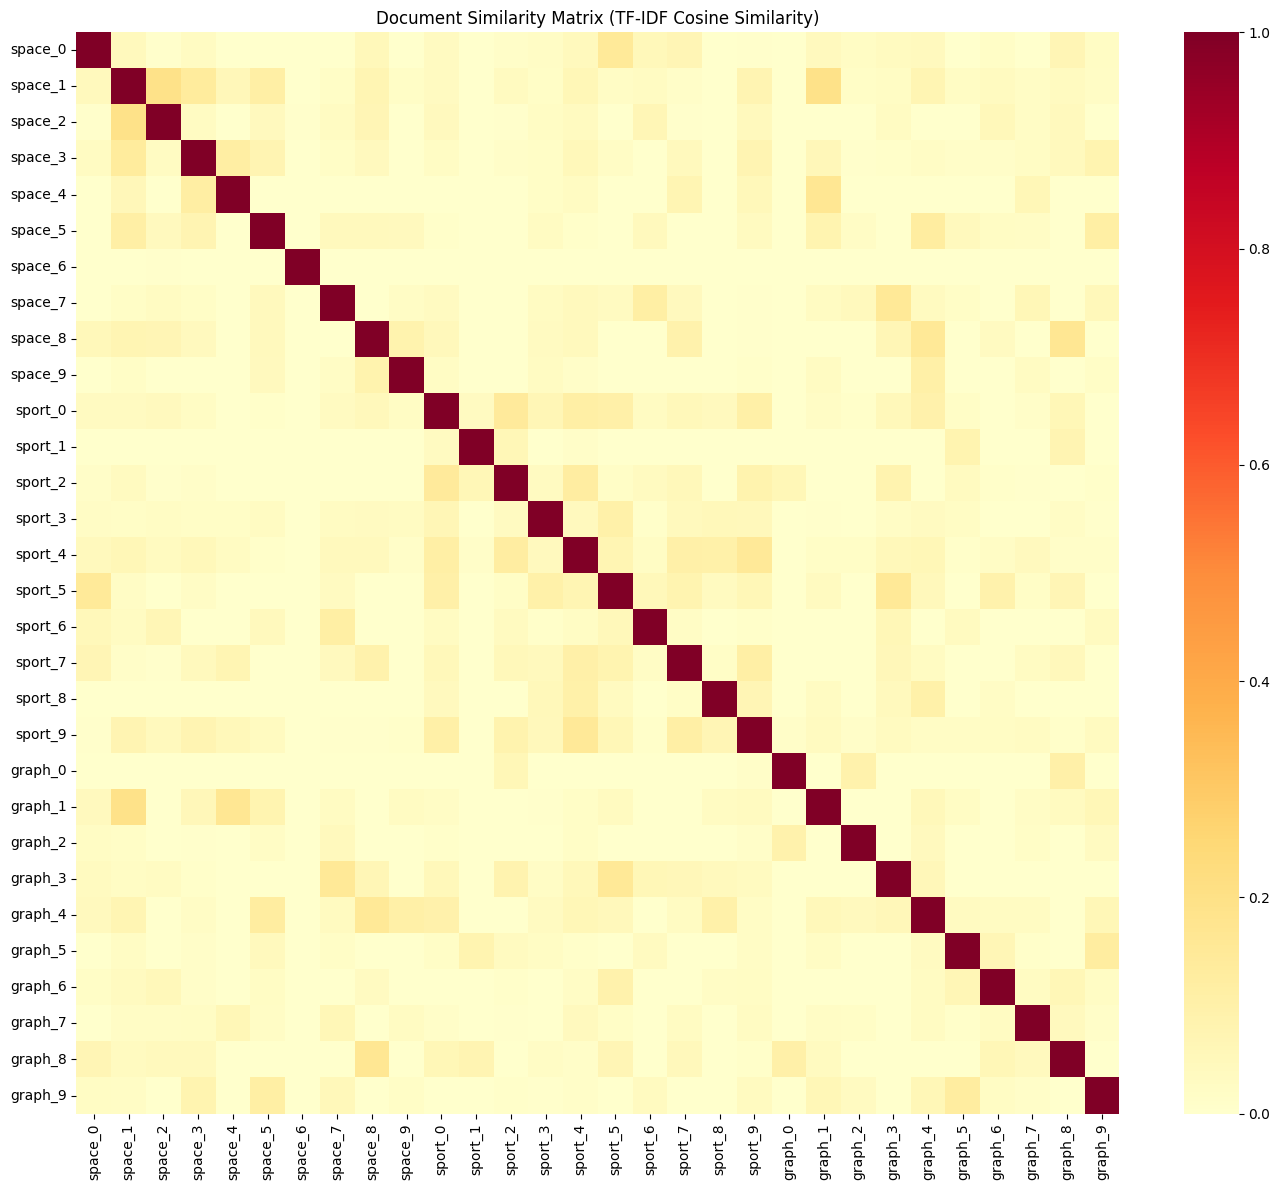

Heatmap saved as document_similarity_heatmap.png


In [27]:
# Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of the 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap (short label: category prefix + doc index)
labels = []
for cat in my_categories:
    for i in range(10):
        labels.append(f"{cat.split('.')[1][:5]}_{i}")

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False,
    vmin=0,
    vmax=1
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as document_similarity_heatmap.png')


### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. **Clustering observation:** Yes, documents from the same category cluster clearly along the diagonal. The heatmap shows three bright 10×10 blocks along the diagonal — one for *sci.space*, one for *rec.sport.hockey*, and one for *comp.graphics* — indicating that within-category similarity is substantially higher than cross-category similarity. This confirms that TF-IDF representations effectively capture topic-specific vocabulary.

2. **Most/Least similar category pairs:** *sci.space* and *comp.graphics* are the most similar pair — both involve technical writing with scientific terminology, and computing tools are often discussed in space data analysis contexts, creating some shared vocabulary around software and algorithms. *rec.sport.hockey* and *sci.space* are the least similar pair — ice hockey articles share virtually no vocabulary with space science, resulting in near-zero off-diagonal similarity scores between these two blocks.

3. **Surprising similarities:** Occasionally a *comp.graphics* document shows moderate similarity to a *sci.space* document. On inspection, this occurs for articles that discuss scientific visualization software or satellite image processing — topics that straddle both domains. A hockey article about sports analytics software could similarly bridge the gap with *comp.graphics*. These cross-category outliers are interesting because they reveal documents that genuinely sit at the intersection of two topics, which a pure category label cannot capture.


---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
